In [25]:
import re
import os
import glob
from pathlib import Path
import pandas as pd

results_dir = Path('/Users/tatiana/Documents_new/visor_freqk/results')

# Var path structure (10 parts):
#   results/{sv_root}/{pos_label}/var/{cov_err}/{SV_TYPE}/{size}/{n_label}/{freq}/{k}/filename
#                                 ^^^
# We require 'var' to appear as a path component to select only variation-aware results.

all_files  = sorted(results_dir.rglob('*.allele_frequencies.k*.tsv'))
var_files  = [f for f in all_files
              if 'var' in f.relative_to(results_dir).parts]
skipped    = len(all_files) - len(var_files)

print(f"Total .tsv files found : {len(all_files)}")
print(f"Non-var (skipped)      : {skipped}")
print(f"Var (loaded)           : {len(var_files)}\n")

print(f"{'sv':3s}  {'pos':8s}  {'cov/err':12s}  {'SV':3s}  {'size':5s}  {'n':5s}  {'freq':4s}  {'k':4s}")
print("-" * 70)
for f in var_files:
    p = f.relative_to(results_dir).parts
    # p: sv_root / pos_label / 'var' / cov_err / SV_TYPE / size / n_label / freq / k / file
    print(f"{p[0]:3s}  {p[1]:8s}  {p[3]:12s}  {p[4]:3s}  {p[5]:5s}  {p[6]:5s}  {p[7]:4s}  {p[8]:4s}")

Total .tsv files found : 517
Non-var (skipped)      : 450
Var (loaded)           : 67

sv   pos       cov/err       SV   size   n      freq  k   
----------------------------------------------------------------------
del  pos10mb   cov10_err001  DEL  100bp  n231   f10   k31 
del  pos10mb   cov10_err001  DEL  100bp  n231   f30   k31 
del  pos10mb   cov10_err001  DEL  100bp  n231   f50   k31 
del  pos10mb   cov10_err001  DEL  100bp  n231   f70   k31 
del  pos10mb   cov10_err001  DEL  100bp  n231   f90   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f10   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f30   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f50   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f70   k31 
del  pos10mb   cov10_err001  DEL  10kb   n231   f90   k31 
del  pos10mb   cov10_err001  DEL  1kb    n231   f10   k31 
del  pos10mb   cov10_err001  DEL  1kb    n231   f30   k31 
del  pos10mb   cov10_err001  DEL  1kb    n231   f50   k31 
del  pos10mb   c

In [26]:
len(var_files)

67

In [27]:
var_files

[PosixPath('/Users/tatiana/Documents_new/visor_freqk/results/del/pos10mb/var/cov10_err001/DEL/100bp/n231/f10/k31/var_del_100bp_n231_f10_err001.allele_frequencies.k31.tsv'),
 PosixPath('/Users/tatiana/Documents_new/visor_freqk/results/del/pos10mb/var/cov10_err001/DEL/100bp/n231/f30/k31/var_del_100bp_n231_f30_err001.allele_frequencies.k31.tsv'),
 PosixPath('/Users/tatiana/Documents_new/visor_freqk/results/del/pos10mb/var/cov10_err001/DEL/100bp/n231/f50/k31/var_del_100bp_n231_f50_err001.allele_frequencies.k31.tsv'),
 PosixPath('/Users/tatiana/Documents_new/visor_freqk/results/del/pos10mb/var/cov10_err001/DEL/100bp/n231/f70/k31/var_del_100bp_n231_f70_err001.allele_frequencies.k31.tsv'),
 PosixPath('/Users/tatiana/Documents_new/visor_freqk/results/del/pos10mb/var/cov10_err001/DEL/100bp/n231/f90/k31/var_del_100bp_n231_f90_err001.allele_frequencies.k31.tsv'),
 PosixPath('/Users/tatiana/Documents_new/visor_freqk/results/del/pos10mb/var/cov10_err001/DEL/10kb/n231/f10/k31/var_del_10kb_n231_f10_e

In [28]:
rows = []

for f in var_files:
    p = f.relative_to(results_dir).parts
    # Two possible var path structures:
    #
    # OLD (9 parts, no n_samples dir):
    #   sv / pos / 'var' / cov_err / SV_TYPE / size / freq / k / file
    #    0    1      2       3         4        5      6     7    8
    #
    # NEW (10 parts, with n_samples dir):
    #   sv / pos / 'var' / cov_err / SV_TYPE / size / n_lbl / freq / k / file
    #    0    1      2       3         4        5       6       7    8    9

    sv_root   = p[0]
    pos_label = p[1]
    cov_err   = p[3]
    sv_type   = p[4]
    size      = p[5]

    # Detect structure from p[6]: starts with 'n' → new, 'f' → old
    if p[6].startswith('n'):
        n_lbl    = p[6]
        freq_lbl = p[7]
        k_lbl    = p[8]
    else:
        n_lbl    = None   # unknown for old results
        freq_lbl = p[6]
        k_lbl    = p[7]

    # Parse coverage and error_rate
    cov_part, err_part = cov_err.split('_')
    coverage   = int(cov_part.replace('cov', ''))
    err_str    = err_part.replace('err', '')
    error_rate = 0.0 if err_str == '0' else float('0.' + err_str)

    # Parse n_samples
    n_samples = int(n_lbl.replace('n', '')) if n_lbl else None

    # Parse nominal frequency: f50 → 0.50
    freq_nominal = int(freq_lbl.replace('f', '')) / 100.0

    # Parse k
    k = int(k_lbl.replace('k', ''))

    # Read AF values (single line: 'af_ref|af_alt')
    line     = f.read_text().strip()
    af_parts = line.split('|')
    af_ref   = float(af_parts[0])
    af_alt   = float(af_parts[1]) if len(af_parts) > 1 else float('nan')

    rows.append({
        'sv_root'     : sv_root,
        'sv_type'     : sv_type,
        'pos_label'   : pos_label,
        'cov_err'     : cov_err,
        'coverage'    : coverage,
        'error_rate'  : error_rate,
        'size'        : size,
        'n_samples'   : n_samples,
        'freq_label'  : freq_lbl,
        'freq_nominal': freq_nominal,
        'k_label'     : k_lbl,
        'k'           : k,
        'file'        : str(f),
        'af_ref'      : af_ref,
        'af_alt'      : af_alt,
    })

results_df = pd.DataFrame(rows)

if results_df.empty:
    print("No var results found yet — rerun once pipeline completes.")
else:
    results_df["error"]     = results_df["af_alt"] - results_df["freq_nominal"]
    results_df["abs_error"] = results_df["error"].abs()
    results_df["rel_error"] = results_df["abs_error"] / results_df["freq_nominal"]

    print(f"Loaded {len(results_df)} rows")
    print(f"  positions  : {sorted(results_df['pos_label'].unique())}")
    print(f"  coverages  : {sorted(results_df['coverage'].unique())}")
    print(f"  n_samples  : {sorted(results_df['n_samples'].dropna().unique())}")
    print(f"  error_rates: {sorted(results_df['error_rate'].unique())}")
    print(f"  sizes      : {sorted(results_df['size'].unique())}")
    display(results_df.sort_values(['sv_type', 'coverage', 'pos_label', 'freq_nominal']).head(10))

Loaded 67 rows
  positions  : ['pos10mb', 'pos15mb']
  coverages  : [10, 20, 50]
  n_samples  : [100.0, 231.0]
  error_rates: [0.001]
  sizes      : ['100bp', '10kb', '1kb', '500bp', '5kb']


,sv_root,sv_type,pos_label,cov_err,coverage,error_rate,size,n_samples,freq_label,freq_nominal,k_label,k,file,af_ref,af_alt,error,abs_error,rel_error
0,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,231.0,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.874735,0.125265,0.025265,0.025265,0.252654
5,del,DEL,pos10mb,cov10_err001,10,0.001,10kb,231.0,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.771896,0.228104,0.128104,0.128104,1.281041
10,del,DEL,pos10mb,cov10_err001,10,0.001,1kb,231.0,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,1.000000,0.000000,-0.100000,0.100000,1.000000
15,del,DEL,pos10mb,cov10_err001,10,0.001,500bp,231.0,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.811282,0.188718,0.088718,0.088718,0.887176
20,del,DEL,pos10mb,cov10_err001,10,0.001,5kb,231.0,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,1.000000,0.000000,-0.100000,0.100000,1.000000
1,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,231.0,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.886893,0.113107,-0.186893,0.186893,0.622978
6,del,DEL,pos10mb,cov10_err001,10,0.001,10kb,231.0,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.752931,0.247069,-0.052931,0.052931,0.176438
11,del,DEL,pos10mb,cov10_err001,10,0.001,1kb,231.0,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.799320,0.200680,-0.099320,0.099320,0.331066
16,del,DEL,pos10mb,cov10_err001,10,0.001,500bp,231.0,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.653814,0.346186,0.046186,0.046186,0.153954
21,del,DEL,pos10mb,cov10_err001,10,0.001,5kb,231.0,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.495727,0.504274,0.204274,0.204274,0.680912


In [29]:
# ── Compute error metrics ──────────────────────────────────────────────────────
results_df["error"]     = results_df["af_alt"] - results_df["freq_nominal"]   # signed bias
results_df["abs_error"] = results_df["error"].abs()
results_df["rel_error"] = results_df["abs_error"] / results_df["freq_nominal"]

In [30]:
results_df.to_csv('/Users/tatiana/Documents_new/visor_freqk/summaries/results_var_mar17_poslabel.csv',index=False)

/Users/tatiana/mambaforge/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tatiana/mambaforge/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


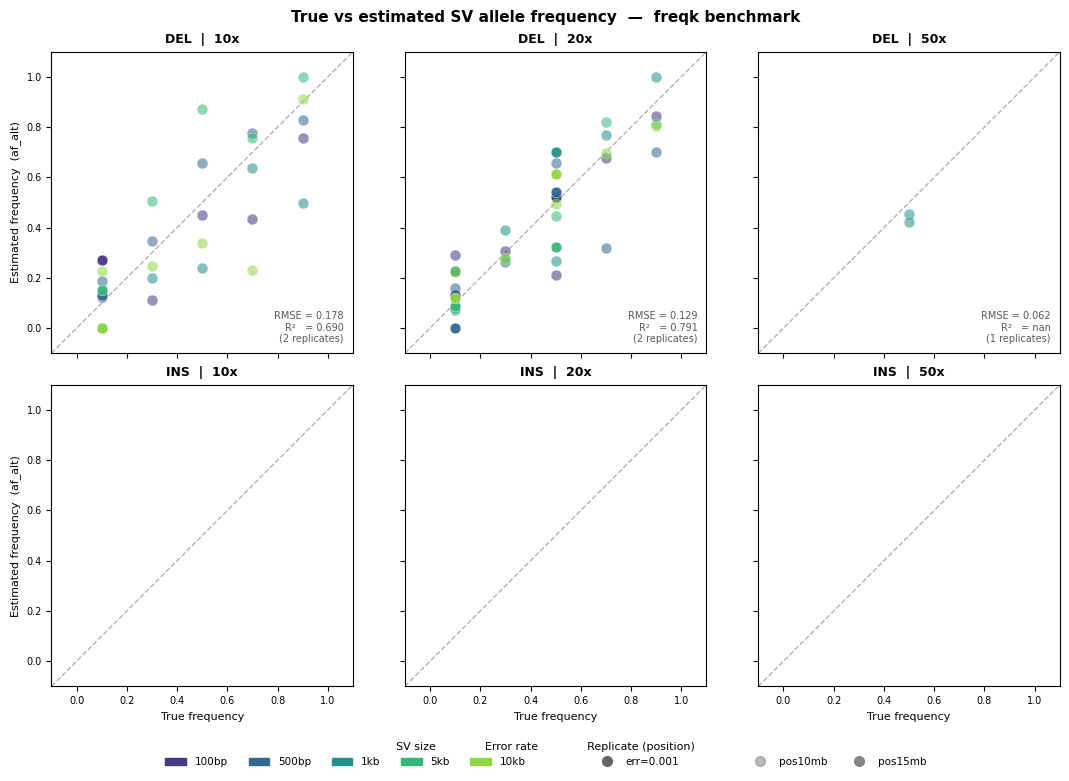

In [31]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from pathlib import Path

# ── Aesthetics ─────────────────────────────────────────────────────────────────
SIZE_ORDER  = ["100bp", "500bp", "1kb", "5kb", "10kb"]
palette     = sns.color_palette("viridis", len(SIZE_ORDER))
SIZE_COLORS = dict(zip(SIZE_ORDER, palette))

# Each error_rate gets a marker shape; positions (replicates) are individual dots
error_rates  = sorted(results_df["error_rate"].unique())
ERR_MARKERS  = dict(zip(error_rates, ["o", "s", "^", "D"]))

# Each replicate position gets an alpha level to make overlap visible
positions    = sorted(results_df["pos_label"].unique())
POS_ALPHA    = {p: a for p, a in zip(positions, np.linspace(0.55, 0.95, len(positions)))}

sv_types  = ["DEL", "INS"]
coverages = sorted(results_df["coverage"].unique())

# ── Layout: rows = sv_type, cols = coverage ────────────────────────────────────
nrows, ncols = len(sv_types), len(coverages)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.6 * ncols, 3.6 * nrows),
    sharex=True, sharey=True,
    constrained_layout=True,
)
if nrows == 1: axes = [axes]
if ncols == 1: axes = [[ax] for ax in axes]

lo, hi = -0.1, 1.1

for i, svt in enumerate(sv_types):
    for j, cov in enumerate(coverages):
        ax = axes[i][j]
        subset = results_df[(results_df["sv_type"] == svt) & (results_df["coverage"] == cov)]

        # Plot every replicate position as a separate dot
        for err in error_rates:
            for size in SIZE_ORDER:
                for pos in positions:
                    pts = subset[
                        (subset["error_rate"] == err) &
                        (subset["size"]       == size) &
                        (subset["pos_label"]  == pos)
                    ]
                    if pts.empty:
                        continue
                    ax.scatter(
                        pts["freq_nominal"], pts["af_alt"],
                        color      = SIZE_COLORS.get(size, "grey"),
                        marker     = ERR_MARKERS.get(err, "x"),
                        alpha      = POS_ALPHA[pos],
                        s          = 60,
                        edgecolors = "white",
                        linewidths = 0.3,
                        zorder     = 3,
                    )

        # Identity line
        ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--", alpha=0.3, zorder=1)

        # RMSE and R² over all replicates
        if not subset.empty:
            rmse  = np.sqrt(((subset["af_alt"] - subset["freq_nominal"]) ** 2).mean())
            r2    = np.corrcoef(subset["freq_nominal"], subset["af_alt"])[0, 1] ** 2
            n_rep = subset["pos_label"].nunique()
            ax.text(0.97, 0.03,
                    f"RMSE = {rmse:.3f}\nR²   = {r2:.3f}\n({n_rep} replicates)",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7, color="0.35",
                    bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.set_title(f"{svt}  |  {cov}x", fontsize=9, fontweight="bold")
        if j == 0:
            ax.set_ylabel("Estimated frequency  (af_alt)", fontsize=8)
        if i == nrows - 1:
            ax.set_xlabel("True frequency", fontsize=8)
        ax.tick_params(labelsize=7)

# ── Legends ────────────────────────────────────────────────────────────────────
size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
err_handles  = [
    mlines.Line2D([], [], color="0.4", marker=ERR_MARKERS[e], linestyle="None",
                  markersize=7, label=f"err={e}")
    for e in error_rates
]
pos_handles  = [
    mlines.Line2D([], [], color="0.5", marker="o", linestyle="None",
                  markersize=7, alpha=POS_ALPHA[p], label=p)
    for p in positions
]

fig.legend(
    handles=size_patches
            + [mpatches.Patch(visible=False)]
            + err_handles
            + [mpatches.Patch(visible=False)]
            + pos_handles,
    title="SV size              Error rate              Replicate (position)",
    loc="lower center",
    ncol=len(SIZE_ORDER) + 1 + len(err_handles) + 1 + len(pos_handles),
    fontsize=7.5, title_fontsize=8,
    bbox_to_anchor=(0.5, -0.07),
    frameon=False,
)

fig.suptitle("True vs estimated SV allele frequency  —  freqk benchmark",
             fontsize=11, fontweight="bold")

Path("/Users/tatiana/Documents_new/visor_freqk/plots/").mkdir(exist_ok=True)
fig.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_estimated_var.pdf", bbox_inches="tight")
fig.savefig("/Users/tatiana/Documents_new/visor_freqk/plots/true_vs_estimated_var.png", bbox_inches="tight", dpi=150)
plt.show()


In [22]:
results_df

,sv_root,sv_type,pos_label,cov_err,coverage,error_rate,size,freq_label,freq_nominal,k_label,k,file,af_ref,af_alt,error,abs_error,rel_error
0,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.896892,0.103108,0.003108,0.003108,0.031082
1,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.753996,0.246004,-0.053996,0.053996,0.179986
2,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.598318,0.401682,-0.098318,0.098318,0.196636
3,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.222567,0.777433,0.077433,0.077433,0.110619
4,del,DEL,pos10mb,cov10_err001,10,0.001,100bp,f90,0.9,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.392157,0.607843,-0.292157,0.292157,0.324619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f10,0.1,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.916493,0.083506,-0.016494,0.016494,0.164935
446,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f30,0.3,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.649575,0.350425,0.050425,0.050425,0.168083
447,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f50,0.5,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.471573,0.528428,0.028428,0.028428,0.056855
448,ins,INS,pos30mb,cov50_err001,50,0.001,5kb,f70,0.7,k31,31,/Users/tatiana/Documents_new/visor_freqk/resul...,0.225225,0.774775,0.074775,0.074775,0.106822
